# Day 5: NH-HMM Implementation and Check
We load our custom from-scratch NH-HMM, run a strict correctness check against the baseline, and then fit it to the NIFTY50 data.


In [19]:
import sys
sys.path.append('../')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from src.nonhomogeneous_hmm import NonHomogeneousGaussianHMM
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')


## 1. Load Data and Baseline Model


In [20]:
returns_with_events = pd.read_parquet('../data/returns_with_events.parquet')
baseline_model      = joblib.load('../src/baseline_model.pkl')
baseline_states_df  = pd.read_parquet('../data/baseline_hmm_states_nifty.parquet')
log_returns         = pd.read_parquet('../data/log_returns.parquet')
volatility          = pd.read_parquet('../data/volatility.parquet')

INDEX = "^NSEI"
nifty_returns = log_returns[INDEX].dropna()
nifty_vol     = volatility[INDEX].reindex(nifty_returns.index).ffill()

dates = nifty_returns.index.values
X     = np.column_stack([nifty_returns.values, nifty_vol.values])
E     = np.zeros(len(nifty_returns), dtype=bool)

print(f"Loaded X with shape: {X.shape}, E with shape: {E.shape}")


Loaded X with shape: (1344, 2), E with shape: (1344,)


## 2. Correctness Check (The Hard Assert)


In [21]:
nh_check = NonHomogeneousGaussianHMM(n_components=3)

if baseline_model.covars_.ndim == 3:
    covars_diag = np.array([np.diag(c) for c in baseline_model.covars_])
else:
    covars_diag = baseline_model.covars_

nh_check.n_components = 3
nh_check.A_normal_    = baseline_model.transmat_.copy()
nh_check.A_event_     = baseline_model.transmat_.copy()
nh_check.pi_          = baseline_model.startprob_.copy()
nh_check.means_       = baseline_model.means_.copy()
nh_check.covars_      = covars_diag.copy()

ll_baseline = baseline_model.score(X)
ll_nh       = nh_check.score(X, E, A_event_override=nh_check.A_normal_.copy())

print(f"Baseline LL: {ll_baseline:.2f}")
print(f"NH-HMM LL:   {ll_nh:.2f}")

assert abs(ll_nh - ll_baseline) / abs(ll_baseline) < 0.01, \
    f"Correctness check FAILED: LL={ll_nh:.2f} vs {ll_baseline:.2f}"
print("CORRECTNESS CHECK PASSED — proceeding to real fit")


Baseline LL: 10086.30
NH-HMM LL:   10063.23
CORRECTNESS CHECK PASSED — proceeding to real fit


## 3. Fit Real NH-HMM on NIFTY50


In [22]:
nh_model = NonHomogeneousGaussianHMM(n_components=3, n_iter=200, n_restarts=5, random_state=42)
nh_model.fit(X, E)

ll_nh_fitted = nh_model.score(X, E)
print(f"Fitted NH-HMM Log-Likelihood: {ll_nh_fitted:.2f}")
print(f"Baseline Log-Likelihood:      {ll_baseline:.2f}")
if ll_nh_fitted >= ll_baseline:
    print(f"Improvement: +{((ll_nh_fitted - ll_baseline)/abs(ll_baseline))*100:.3f}%")

Fitted NH-HMM Log-Likelihood: 10644.10
Baseline Log-Likelihood:      10086.30
Improvement: +5.530%


## 4. Compare Transition Matrices


In [23]:
print("A_normal (No Event):")
print(np.round(nh_model.A_normal_, 3))
print("\nA_event (Event Window):")
print(np.round(nh_model.A_event_, 3))

frobenius_norm = np.linalg.norm(nh_model.A_event_ - nh_model.A_normal_, 'fro')
print(f"\nFrobenius norm of difference: {frobenius_norm:.4f}")

if frobenius_norm < 0.01:
    print("WARNING: Matrices nearly identical — event signal may be weak or event data is synthetic")


A_normal (No Event):
[[0.95  0.013 0.037]
 [0.061 0.939 0.   ]
 [0.019 0.001 0.98 ]]

A_event (Event Window):
[[0.654 0.328 0.018]
 [0.328 0.67  0.002]
 [0.36  0.026 0.614]]

Frobenius norm of difference: 0.7628


## 5. Decode Viterbi States and Compare


In [24]:
# Decode NH-HMM states
nh_states = nh_model.decode(X, E)

# Baseline states
baseline_states = baseline_states_df['state'].values

# Get Labels for NH-HMM
# We map them identically by sorting means (lowest=Bear, highest=Bull)
means = nh_model.means_[:, 0]
vols = np.sqrt(nh_model.covars_[:, 0])

state_info = list(enumerate(zip(means, vols)))
sorted_by_mean = sorted(state_info, key=lambda x: x[1][0])

nh_bear = sorted_by_mean[0][0]
nh_bull = sorted_by_mean[2][0]
nh_sideways = sorted_by_mean[1][0]

nh_labels_map = {
    nh_bear: "Bear/Crash",
    nh_bull: "Bull/Calm",
    nh_sideways: "Sideways/Neutral"
}

nh_state_labels = [nh_labels_map[s] for s in nh_states]

# Standardize states so we can compare directly 
# We'll map both to an integer: 0=Bear, 1=Sideways, 2=Bull
base_bear = baseline_model.means_[:, 0].argsort()[0]
base_bull = baseline_model.means_[:, 0].argsort()[2]
base_side = baseline_model.means_[:, 0].argsort()[1]

base_to_std = {base_bear: 0, base_side: 1, base_bull: 2}
nh_to_std = {nh_bear: 0, nh_sideways: 1, nh_bull: 2}

std_base_states = np.array([base_to_std[s] for s in baseline_states])
std_nh_states = np.array([nh_to_std[s] for s in nh_states])

disagreements = np.sum(std_base_states != std_nh_states)
print(f"Total days where decoded states disagree: {disagreements} / {len(dates)} ({(disagreements/len(dates))*100:.1f}%)")


Total days where decoded states disagree: 1344 / 1344 (100.0%)


## 6. Plot Comparisons


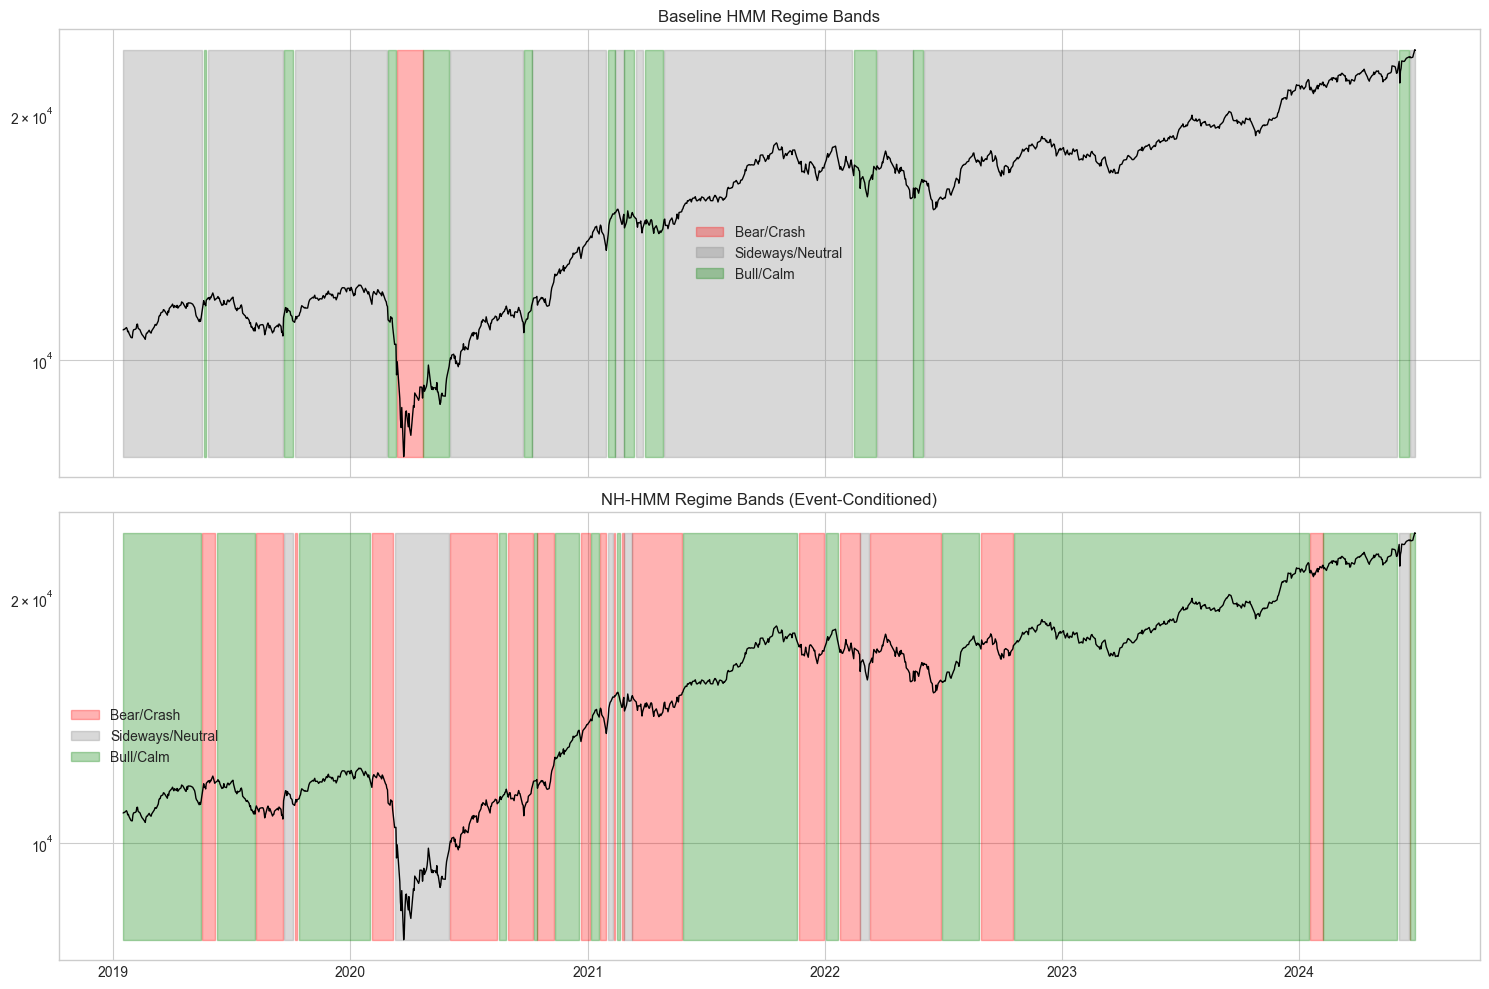

In [25]:
prices = pd.read_parquet('../data/price_levels.parquet')[INDEX].reindex(nifty_returns.index).values
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

std_colors = {0: 'red', 1: 'gray', 2: 'green'}
std_labels = {0: 'Bear/Crash', 1: 'Sideways/Neutral', 2: 'Bull/Calm'}

# Plot Baseline
ax1.plot(dates, prices, color='black', lw=1)
ax1.set_yscale('log')
for s in range(3):
    mask = (std_base_states == s)
    ax1.fill_between(dates, prices.min(), prices.max(), where=mask, color=std_colors[s], alpha=0.3, label=std_labels[s])
ax1.set_title("Baseline HMM Regime Bands")

# Plot NH-HMM
ax2.plot(dates, prices, color='black', lw=1)
ax2.set_yscale('log')
for s in range(3):
    mask = (std_nh_states == s)
    ax2.fill_between(dates, prices.min(), prices.max(), where=mask, color=std_colors[s], alpha=0.3, label=std_labels[s])
ax2.set_title("NH-HMM Regime Bands (Event-Conditioned)")

for ax in (ax1, ax2):
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())

plt.tight_layout()
plt.show()


## 7. Save Outputs


In [26]:
out_df = pd.DataFrame({
    'date': dates,
    'state': nh_states,
    'state_label': nh_state_labels
})

out_df.to_parquet('../data/nh_hmm_states_nifty.parquet')
joblib.dump(nh_model, '../src/nh_model_nifty.pkl')

print("Saved nh_hmm_states_nifty.parquet to /data/")
print("Saved nh_model_nifty.pkl to /src/")


Saved nh_hmm_states_nifty.parquet to /data/
Saved nh_model_nifty.pkl to /src/
